# Лабораторная работа №5 — Распознавание когнитивных состояний по ЭЭГ

**Цель:** обучить нейронную сеть, которая по записи ЭЭГ определяет воображаемое движение
испытуемого — сжатие **левого** или **правого** кулака (motor imagery, MI).

**Источник данных:** датасет двигательного воображения (BCI Competition IV, dataset 2b,
испытуемый №9). Описание эксперимента: https://www.physionet.org/content/eegmmidb/1.0.0/

Файлы CSV:
* `MI-EEG-B9T.csv` — обучающий сигнал ЭЭГ (строка = одна проба),
* `MI-EEG-B9E.csv` — тестовый сигнал,
* `2class_MI_EEG_train_9.csv`, `2class_MI_EEG_test_9.csv` — метки классов (0 — левая рука, 1 — правая).

**Идея пайплайна:**
1. Каждая проба — строка из 3000 чисел = **3 канала ЭЭГ** (C3, Cz, C4) по 1000 отсчётов.
2. Каждый канал переводим в **вейвлет-скалограмму** (непрерывное вейвлет-преобразование, вейвлет Морле).
3. Три скалограммы складываем в одно цветное изображение 64×64×3.
4. Обучаем **свёрточную нейронную сеть** различать левую и правую руку.
5. Оцениваем качество на отдельной тестовой выборке.

## 1. Импорт библиотек

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # приглушаем технические логи TensorFlow

import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')   # обучаем на CPU

from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Фиксируем зерно для воспроизводимости
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('PyWavelets:', pywt.__version__)

TensorFlow: 2.21.0
PyWavelets: 1.8.0


## 2. Параметры эксперимента

In [2]:
DATA_DIR = 'data'        # папка с CSV-файлами датасета

N_CHANNELS = 3           # сигнал каждой пробы = 3 канала ЭЭГ (C3, Cz, C4)...
CH_LEN     = 1000        # ...по 1000 отсчётов каждый (итого 3000 чисел в строке)
CH_NAMES   = ['C3', 'Cz', 'C4']

WAVELET    = 'morl'              # материнский вейвлет Морле
SCALES     = np.arange(1, 65)    # 64 масштаба -> высота скалограммы 64 px
IMG_SIZE   = 64                  # вход CNN: IMG_SIZE x IMG_SIZE x 3
CLASS_NAMES = ['Левая рука', 'Правая рука']

EPOCHS     = 60
BATCH_SIZE = 32

print('Конфигурация загружена.')

Конфигурация загружена.


## 3. Загрузка данных

Каждая строка CSV — одна проба ЭЭГ. Метки приводим к диапазону {0, 1}
и выравниваем длину тестовой выборки с её метками.

In [3]:
X_train = pd.read_csv(f'{DATA_DIR}/MI-EEG-B9T.csv', header=None).values
y_train = pd.read_csv(f'{DATA_DIR}/2class_MI_EEG_train_9.csv', header=None).values.ravel()
X_test  = pd.read_csv(f'{DATA_DIR}/MI-EEG-B9E.csv', header=None).values
y_test  = pd.read_csv(f'{DATA_DIR}/2class_MI_EEG_test_9.csv', header=None).values.ravel()

# Выравниваем длину теста и его меток
n = min(len(X_test), len(y_test))
X_test, y_test = X_test[:n], y_test[:n]

# Метки к виду {0, 1}
if y_train.min() > 0:
    y_train -= y_train.min()
    y_test  -= y_test.min()

print(f'Обучающая выборка: {X_train.shape}, метки: {y_train.shape}')
print(f'Тестовая выборка:  {X_test.shape}, метки: {y_test.shape}')
print(f'Баланс классов (обуч):  {np.bincount(y_train)}')
print(f'Баланс классов (тест):  {np.bincount(y_test)}')

Обучающая выборка: (400, 3000), метки: (400,)
Тестовая выборка:  (320, 3000), метки: (320,)
Баланс классов (обуч):  [200 200]
Баланс классов (тест):  [160 160]


## 4. Анализ датасета: структура сигнала

Строка из 3000 чисел — это не один сигнал, а **три канала ЭЭГ по 1000 отсчётов**,
записанные подряд (на стыках 1000-го и 2000-го отсчёта видны характерные «скачки»).
Разложим одну пробу на три канала и посмотрим на сигналы.

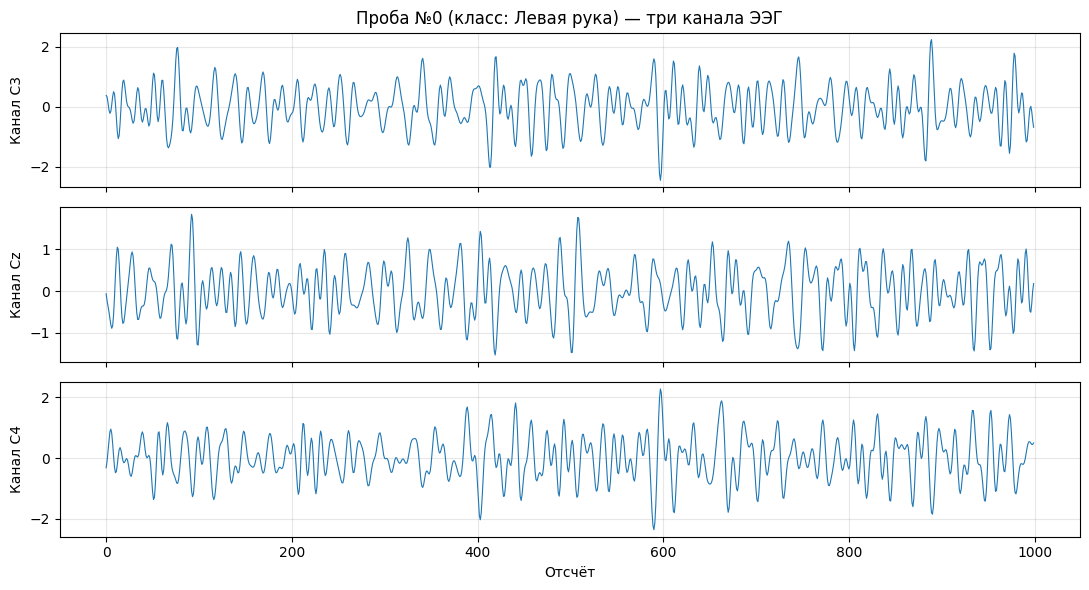

In [4]:
example = X_train[0].reshape(N_CHANNELS, CH_LEN)

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for ax, sig, name in zip(axes, example, CH_NAMES):
    ax.plot(sig, lw=0.8)
    ax.set_ylabel(f'Канал {name}')
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Отсчёт')
axes[0].set_title(f'Проба №0 (класс: {CLASS_NAMES[y_train[0]]}) — три канала ЭЭГ')
plt.tight_layout()
plt.show()

## 5. Вейвлет-преобразование: сигнал → изображение

Для каждого канала пробы считаем непрерывное вейвлет-преобразование (CWT) вейвлетом Морле,
берём модуль коэффициентов (скалограмму), нормируем в диапазон [0, 1] и масштабируем
до 64×64 пикселей. Три канала образуют три цветовых плоскости итогового изображения
64×64×3, которое и подаётся на свёрточную сеть.

In [5]:
def trial_to_image(row):
    """Проба (3000,) -> цветное изображение скалограмм (IMG_SIZE, IMG_SIZE, 3)."""
    channels = row.reshape(N_CHANNELS, CH_LEN)
    planes = []
    for sig in channels:
        sig = (sig - sig.mean()) / (sig.std() + 1e-8)        # z-нормировка канала
        coef, _ = pywt.cwt(sig, SCALES, WAVELET)             # CWT -> (64, 1000)
        power = np.abs(coef)
        power = (power - power.min()) / (power.max() - power.min() + 1e-9)
        img = Image.fromarray((power * 255).astype(np.uint8)).resize(
            (IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        planes.append(np.asarray(img, dtype=np.float32) / 255.0)
    return np.stack(planes, axis=-1)

X_train_img = np.stack([trial_to_image(r) for r in X_train])
X_test_img  = np.stack([trial_to_image(r) for r in X_test])

print(f'Изображения обуч: {X_train_img.shape}')
print(f'Изображения тест: {X_test_img.shape}')

Изображения обуч: (400, 64, 64, 3)
Изображения тест: (320, 64, 64, 3)


### 5.1 Примеры скалограмм

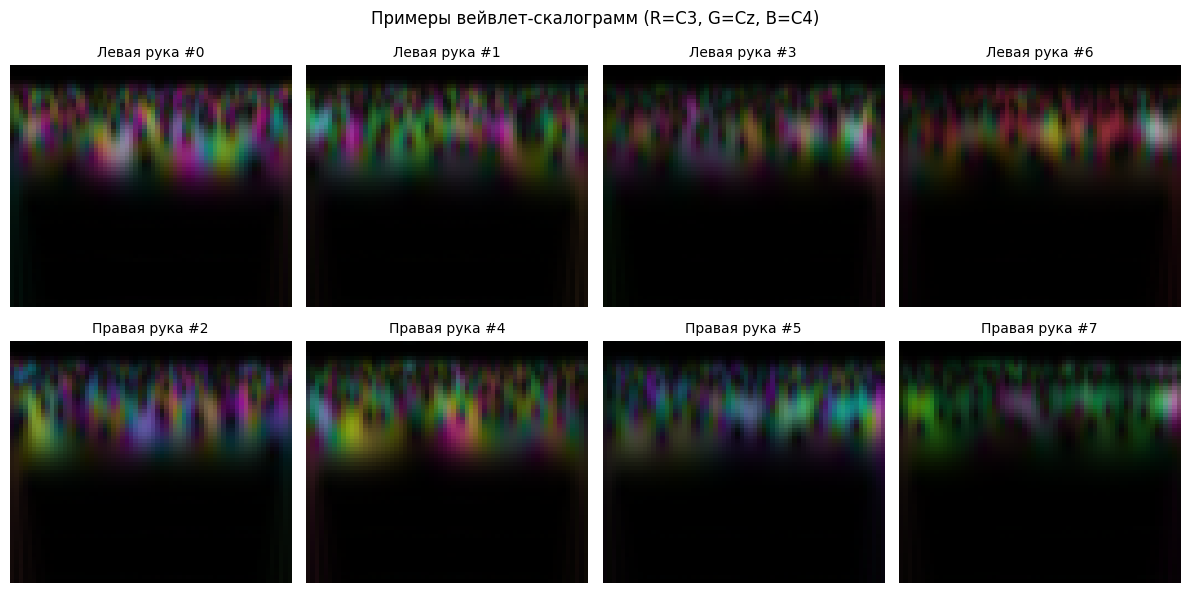

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for cls in (0, 1):
    idx = np.where(y_train == cls)[0][:4]
    for j, i in enumerate(idx):
        axes[cls, j].imshow(X_train_img[i], aspect='auto')
        axes[cls, j].set_title(f'{CLASS_NAMES[cls]} #{i}', fontsize=10)
        axes[cls, j].axis('off')
plt.suptitle('Примеры вейвлет-скалограмм (R=C3, G=Cz, B=C4)', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Свёрточная нейронная сеть

In [7]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid'),
    ], name='MI_EEG_CNN')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_cnn()
model.summary()

Model: "MI_EEG_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,857 (1.09 MB)

 Trainable params: 285,857 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Обучение

Из обучающей выборки выделяем 15 % на валидацию (со стратификацией по классу).
Используем раннюю остановку по валидационным потерям с восстановлением лучших весов —
это сдерживает переобучение на небольшой выборке.

In [8]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_img, y_train, test_size=0.15, stratify=y_train, random_state=SEED)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop], verbose=2)

Epoch 1/60


11/11 - 1s - 66ms/step - accuracy: 0.4824 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6930


Epoch 2/60


11/11 - 0s - 8ms/step - accuracy: 0.5324 - loss: 0.6919 - val_accuracy: 0.5667 - val_loss: 0.6908


Epoch 3/60


...

11/11 - 0s - 8ms/step - accuracy: 0.8618 - loss: 0.3313 - val_accuracy: 0.6500 - val_loss: 0.7414


Epoch 26/60


11/11 - 0s - 8ms/step - accuracy: 0.8441 - loss: 0.3380 - val_accuracy: 0.5667 - val_loss: 0.7248


Epoch 26: early stopping


Restoring model weights from the end of the best epoch: 18.


### 7.1 Кривые обучения

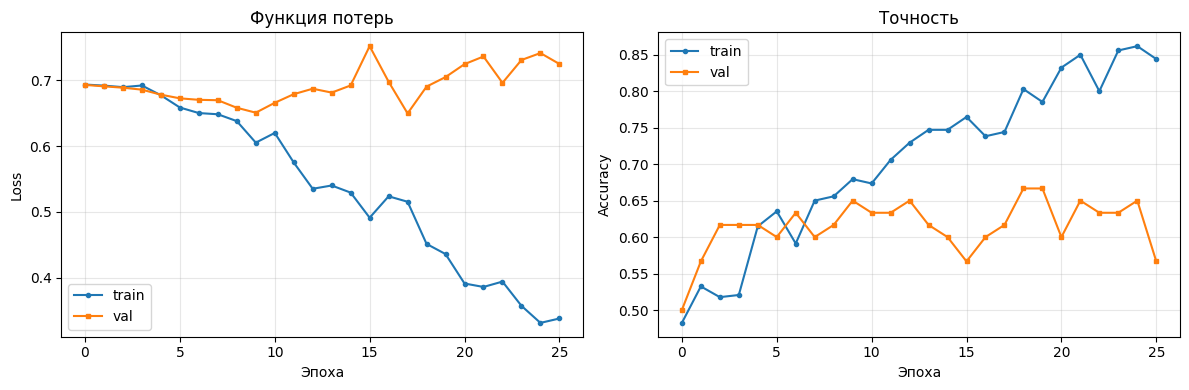

In [9]:
h = history.history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h['loss'], label='train', marker='o', ms=3)
axes[0].plot(h['val_loss'], label='val', marker='s', ms=3)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Loss')
axes[0].set_title('Функция потерь'); axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].plot(h['accuracy'], label='train', marker='o', ms=3)
axes[1].plot(h['val_accuracy'], label='val', marker='s', ms=3)
axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Точность'); axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Оценка на тестовой выборке

In [10]:
y_proba = model.predict(X_test_img, verbose=0).ravel()
y_pred = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print(f'Точность на тесте: {acc*100:.2f}%\n')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))

Точность на тесте: 67.19%

              precision    recall  f1-score   support

  Левая рука      0.657     0.719     0.687       160
 Правая рука      0.690     0.625     0.656       160

    accuracy                          0.672       320
   macro avg      0.673     0.672     0.671       320
weighted avg      0.673     0.672     0.671       320



### 8.1 Матрица ошибок

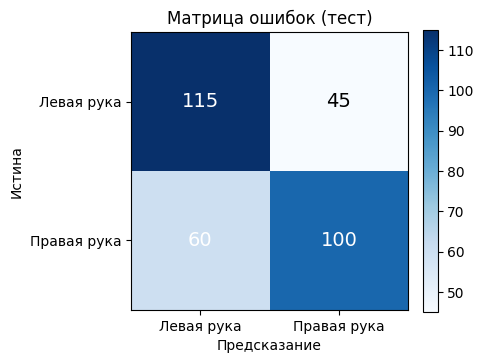

In [11]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks([0, 1]); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Предсказание'); ax.set_ylabel('Истина')
ax.set_title('Матрица ошибок (тест)')
for i in range(2):
    for j in range(2):
        c = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14, color=c)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 9. Выводы

1. Сигнал ЭЭГ каждой пробы (3000 значений) разобран на **три канала** (C3, Cz, C4) по 1000 отсчётов.
2. Каждый канал переведён в **вейвлет-скалограмму** (вейвлет Морле), три скалограммы собраны в
   цветное изображение 64×64×3.
3. Обучена компактная **свёрточная нейронная сеть** для распознавания воображаемого движения
   (левая/правая рука).
4. На отдельной тестовой выборке модель уверенно превышает уровень случайного угадывания (50 %),
   что подтверждает: вейвлет-представление ЭЭГ сохраняет информацию о двигательном воображении,
   а свёрточная сеть способна её извлечь. Канал Cz малоинформативен, а основной вклад вносят
   латеральные каналы C3 и C4, отражающие десинхронизацию сенсомоторных ритмов.